## This notebook is depricated.  Please use cap_currents.ipynb or waveform_6state_sandbox.ipynb notebooks instead

In [1]:
import libs.append_path
from add_python_libraries import *
import pd_filter_fcns

import scipy as sp
import scipy.signal
import scipy.fftpack
import numpy as np
import matplotlib.pyplot as plt

In [2]:
inp_params = {'vin':20,
              'vout':11,
              'pin':100,
              'eff':0.97,
              'fs':350e3,  #inductor ripple freq
              'lout':1e-6,
              'ddiv':2}
vin = inp_params['vin']
vout = inp_params['vout']

In [3]:
class Circuit_params:
    def __init__(self,ip):
        self.ip = ip
        vin = ip['vin']; vout = ip['vout']; fs = ip['fs']; self.lout = ip['lout']
        self.iout = self.ip['pin']*self.ip['eff']/vout
        
        self.ddiv = ip['ddiv']       
        d_2state = vout/vin
        self.tstate = {'ts':1/fs}
        self.tstate[1] = d_2state/self.ddiv*self.tstate['ts']
        self.tstate[2] = self.tstate[1]*2*(self.ddiv-1)  
        self.tstate[3] = self.tstate['ts'] - self.tstate[1]-self.tstate[2]
        
        self.tstate = {state:round(t,10) for state,t in self.tstate.items()}     
        self.tstart = {1:0,
                       2:self.tstate[1],
                       3:self.tstate[1]+self.tstate[2]}      
        self.tend = {state:self.tstart[state]+self.tstate[state] for state in self.tstate.keys() if isinstance(state,int)}
        self.deltaV = {1:vin-vout, 2:vin/2-vout, 3:-vout}
        self.voltsecmax = max([abs(self.deltaV[state]*self.tstate[state]) for state in self.tstate.keys() if isinstance(state,int)])

        self.ipp = {state:round(dv*self.tstate[state]/self.lout,3) for state,dv in self.deltaV.items()}   
        self.ipp['ts'] = max(self.ipp[1],abs(self.ipp[3]))
        self.i_start = {1:0,
                        2:self.ipp[1],
                        3:self.ipp[1]+self.ipp[2]}
        self.avg = float(round(self.waveform(np.linspace(0,self.tstate['ts'],100)).mean(),3))

    def conditions(self,t):
        return [t < self.tend[1], (t>=self.tend[1]) & (t<self.tend[2]), t>=self.tend[2]]
        
    def functions(self):
        return [lambda x:self.i_start[1]+self.deltaV[1]*(x-self.tstart[1])/self.lout, 
                 lambda x:self.i_start[2]+self.deltaV[2]*(x-self.tstart[2])/self.lout, 
                 lambda x:self.i_start[3]+self.deltaV[3]*(x-self.tstart[3])/self.lout]

    def waveform(self,t):
        return np.piecewise(t,self.conditions(t),self.functions())


In [4]:
d2 = Circuit_params(inp_params)
inp_params['ddiv']=3; d3 = Circuit_params(inp_params)
inp_params['ddiv']=4; d4 = Circuit_params(inp_params)

In [5]:
t = np.linspace(0, d2.tstate['ts'], 512)

wf2 = d2.waveform(t)
wf3 = d3.waveform(t)
wf4 = d4.waveform(t)
#waveform = cp3s.waveform(t) #np.piecewise(t, cp3s.conditions(t), cp3s.functions())

In [6]:
# t_2cycles = np.concatenate((t,t_2ndperiod))
# wf_2cycles = np.concatenate((wf2,wf2))

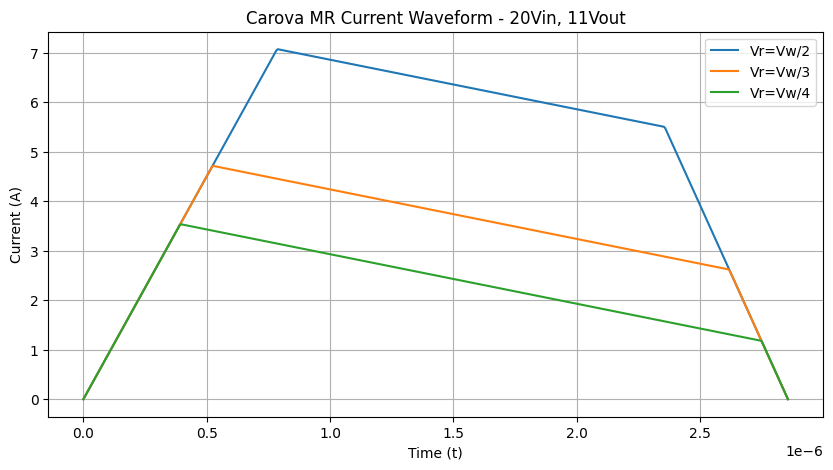

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(t, wf2, label='Vr=Vw/2')
plt.plot(t, wf3, label='Vr=Vw/3')
plt.plot(t, wf4, label='Vr=Vw/4')
plt.title(f'Carova MR Current Waveform - {vin}Vin, {vout}Vout'); plt.xlabel('Time (t)'); plt.ylabel('Current (A)')
plt.legend(); plt.grid(True)
plt.show()

In [31]:
ts=1/d2.ip['fs']
t_2ndperiod = t+ts
t_2cycles = np.concatenate((t,t_2ndperiod))
wf_2cycles = np.concatenate((wf2,wf2))
I_lout = wf_2cycles-d2.avg+d2.iout

d_hs_1stcycle = d2.tstate[1]+d2.tstate[2]
D_pulse_1stcycle = sp.signal.square(2*np.pi*t,d_hs_1stcycle)/2+0.5
d_hs_2ndcycle = d2.tstate[1]
D_pulse_2ndcycle = sp.signal.square(2*np.pi*t,d_hs_2ndcycle)/2+0.5
D_pulse_2cycles = np.concatenate((D_pulse_1stcycle,D_pulse_2ndcycle))

hs = D_pulse_2cycles*I_lout
I_zin_ac = hs-np.mean(hs)

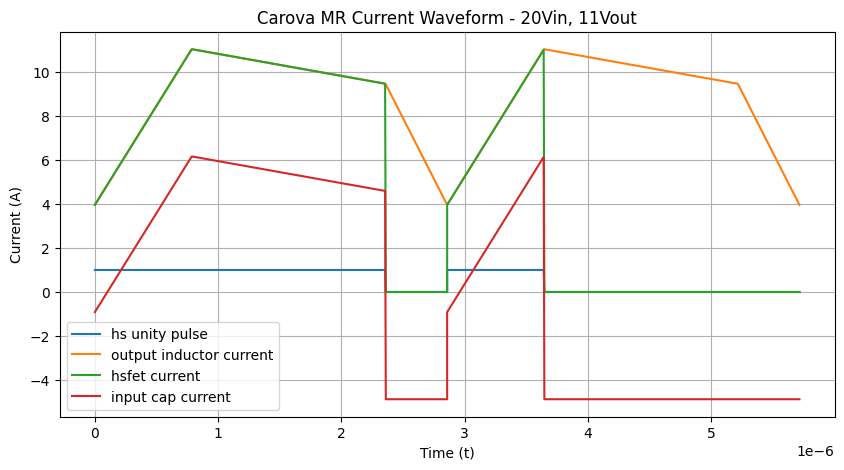

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(t_2cycles, D_pulse_2cycles, label='hs unity pulse')
plt.plot(t_2cycles, I_lout, label='output inductor current')
plt.plot(t_2cycles, hs, label='hsfet current')
plt.plot(t_2cycles,I_zin_ac, label='input cap current')
plt.title(f'Carova MR Current Waveform - {vin}Vin, {vout}Vout'); plt.xlabel('Time (t)'); plt.ylabel('Current (A)')
plt.legend(); plt.grid(True)
plt.show()

In [18]:
from current_capbanks_fft import Current_capbanks_FFT

In [19]:
class Current_buckcarova_FFT:
    def __init__(self,timedata,wavedata,fs):
        self.timestep=timedata[1]
        self.Fs = fs
        self.i_zin_ac = wavedata
        self.i_zin_fft = sp.fft.fft(self.i_zin_ac) #[:int(self.numpoints/2)]) if 4 cycles instead of 2
        self.freq = sp.fft.fftfreq(self.i_zin_fft.size,self.timestep)

    def plot_i_zin_fft(self):
        i_zin_fft_mag = np.abs(self.i_zin_fft)
        ampscale=2/self.i_zin_fft.size
        xticks = np.arange(8)*self.Fs
        i=self.freq>=0
        bar_width=100000
        fig,ax = plt.subplots(1,1,figsize=(8,4))
        rects1=ax.bar(self.freq[i],ampscale*i_zin_fft_mag[i],bar_width)
        ax.set_xlim(0,8*self.Fs)
        ax.set_xticks(xticks)
        plt.show()


In [20]:
currents_buckfftobj = Current_buckcarova_FFT(t_2cycles,I_zin_ac,350000)

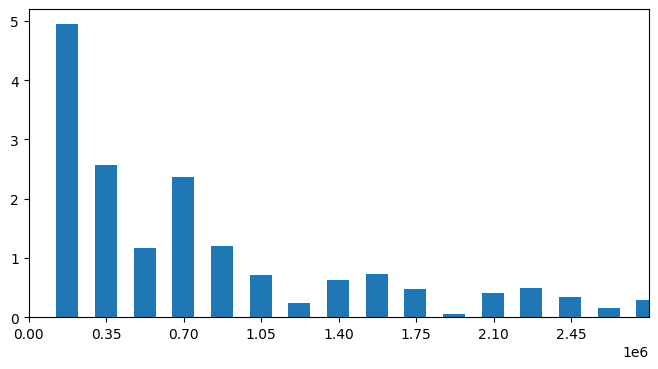

In [21]:
currents_buckfftobj.plot_i_zin_fft()

In [22]:
Csp   = {'label':'sp1','type':'sp',  'C':10e-6,  'ESR':100e-3, 'ESL':2e-9,   'n':1}
Cmlcc1 = {'label':'mlcc1','type':'mlcc','C':0.9e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':4}
Cmlcc2 = {'label':'mlcc2','type':'mlcc','C':0.52e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':4}
Cmlcc3 = {'label':'mlcc3','type':'mlcc','C':0.052e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':1}
Caplist = [Csp,Cmlcc1,Cmlcc2,Cmlcc3]

In [23]:
from capacitorZ_multibank import Zcapbanks
from current_capbanks_fft import Current_capbanks_FFT
from current_capbanks_waveforms import Current_capbanks_waveforms

In [24]:
zcapbanks = Zcapbanks(Caplist)
currents_capsfftobj = Current_capbanks_FFT(currents_buckfftobj,zcapbanks)

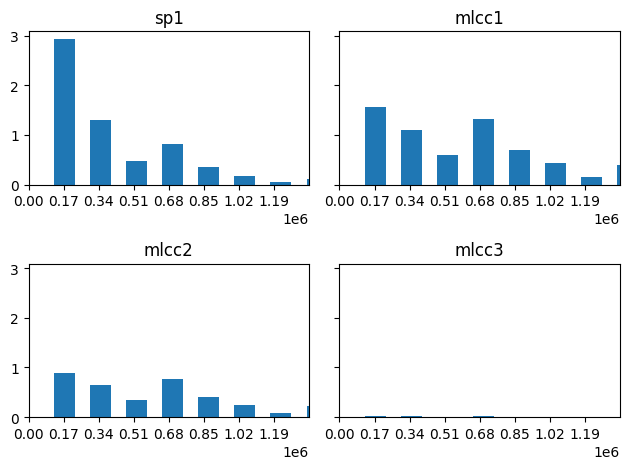

In [25]:
currents_capsfftobj.plot_i_allbanks_fft()

In [26]:
i_zbank_ac_obj = Current_capbanks_waveforms(currents_capsfftobj)

([<matplotlib.lines.Line2D at 0x11277e210>],
 [<matplotlib.lines.Line2D at 0x11277e710>])

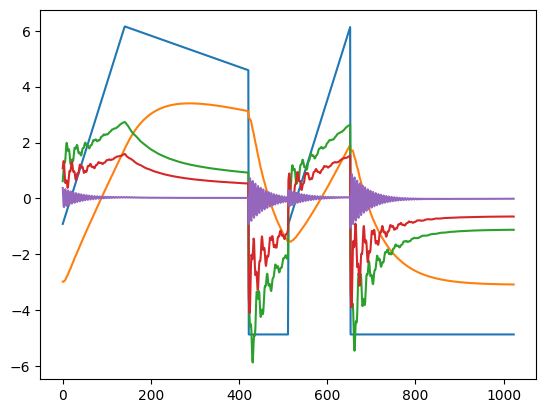

In [27]:
plt.plot(i_zbank_ac_obj.i_total_ac),plt.plot(i_zbank_ac_obj.i_nbanks_ac[0]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[1]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[2]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[3])

In [29]:
import numpy_rms

In [30]:
numpy_rms.rms(i_zbank_ac_obj.i_total_ac),numpy_rms.rms(i_zbank_ac_obj.i_nbanks_ac[0])

(array([4.65679924]), array([2.39117919]))